# ■ 딥러닝 컴페티션

### 컴페티션의 목표는 ① 학습 평가의 이해, ② 딥러닝 성능 개선 방법 숙지, ③ 설명력을 키우는게 목적

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X (상대평가는 안하지만, 개인 성능은 valid score가 75이상 나오길 권장함.)

※ 수업 코드 사용 가능

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. ① 코딩의 인과성, ② 설명의 깊이만 충분하다면, 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 모델 선택, 튜닝 기준 (650자 이내, 주석 서술하기)

4. (25점) 개선사항 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

</br>

## ■ 깃허브 정리 (10점)

1. 포트폴리오로 쓸 수 있도록 프로젝트 제목, 전처리, EDA, 모델링 방법, 성능 결과를 캡처 이미지와 함께 잘 정리.

</br>

## ■ 제출방법

5월 12일 23시 59분까지, 오승환 강사에게 DM으로 ipynb 파일 제출, 이후 깃허브 링크도 정리되는대로 DM 제출

# 1. 원본 데이터 출처

https://www.kaggle.com/datasets/parisrohan/credit-score-classification

# 2. 데이터 클리닝 방법 출처:

https://www.kaggle.com/code/clkmuhammed/credit-score-classification-part-1-data-cleaning#Download-Link

---
---
# 딥러닝 분류 컴페티션 - Credit Score Classification
---
---

- 목표 : `train2.csv`의 고객 금융 정보를 이용해 `Credit_Score`를 분류한다.
- 흐름 : 전처리 -> EDA -> Feature Selection/모델 선택 -> 개선사항 -> Validation Score 출력

In [25]:
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# 시각화 및 한글 폰트 설정 (맥북 VS Code용)
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 시드(Seed) 고정 (재현성 확보)
RANDOM_STATE = 42
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# 디바이스 설정 (Apple Silicon GPU 가속 지원)
# 맥북 M시리즈 칩(MPS)이 사용 가능한지 최우선으로 확인
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    # CUDA 환경(코랩 등)으로 다시 가져갈 경우를 대비한 안전장치
    torch.cuda.manual_seed_all(RANDOM_STATE)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print('device:', device)


device: mps


## 0. 데이터 로드

In [26]:
DATA_PATH = 'train2.csv'

df_raw = pd.read_csv(DATA_PATH)
print('원본 데이터 shape:', df_raw.shape)
display(df_raw.head())
print('\n타깃 분포')
display(df_raw['Credit_Score'].value_counts())
print('\n타깃 비율')
display((df_raw['Credit_Score'].value_counts(normalize=True) * 100).round(2).astype(str) + '%')

원본 데이터 shape: (100000, 28)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,26.822620,265,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,31.944960,266,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629163,Good
2,5636,3392,3,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,28.609352,267,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,5637,3392,4,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,31.377862,268,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,5638,3392,5,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,269,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good



타깃 분포


Credit_Score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64


타깃 비율


Credit_Score
Standard    53.17%
Poor         29.0%
Good        17.83%
Name: proportion, dtype: object

## 1. 전처리 및 파생변수 생성

### [전처리 아이디어 및 논리]
> 신용점수(Good/Standard/Poor)는 식별자가 아닌 상환능력, 상환행동, 신용거래 구조로 결정된다.
1. 식별자 제거
- ID, Customer_ID, Name, SSN은 예측에 무의미하고 과적합(암기) 위험이 있어 제거한다.
2. 대출 유형(Type_of_Loan) 분해
- 원본은 여러 대출 유형이 쉼표(,)로 나열되어 있어 단순 Label Encoding이 불가능하다.
- 대출 종류 수(Num_Loan_Types)와 8종 대출 여부 플래그로 분해해 부채 구조 복잡도를 수치로 표현한다.
- 논리 : 대출 종류가 많을수록, 그리고 Payday Loan(급전 대출) 등 고위험 대출을 보유할수록 신용 리스크가 증가하기 때문이다. 
3. 결제 행동(Payment_Behaviour) 분해
- 소비수준(High/Low)과 결제금액 크기(Small/Medium/Large)로 나눠 행동 특성을 모델이 독립적으로 학습할 수 있게 한다.
4. 도메인 기반 파생변수 생성 (Feature Engineering)
- 절대적인 금액 수치보다, 소득 규모가 다른 개인 간 객관적 비교가 가능한 정규화된 비율 지표를 생성한다.
5. 데이터 누수 방지
- Imputer, Scaler는 반드시 train에만 fit하고 val에는 transform만 적용한다.
-  val 정보가 fit에 포함되면 실제보다 낙관적인 검증 성능이 도출되기 때문이다.

In [27]:
def to_numeric_series(s):
    # 문자열 안의 숫자만 남겨 numeric으로 변환한다. 이미 숫자형이면 그대로 반환한다.
    if pd.api.types.is_numeric_dtype(s):
        return s
    cleaned = s.astype(str).str.replace(r'[^0-9.\-]', '', regex=True)
    cleaned = cleaned.replace({'': np.nan, 'nan': np.nan, 'None': np.nan})
    return pd.to_numeric(cleaned, errors='coerce')

def safe_divide(a, b):
    return a / (b.replace(0, np.nan) + 1e-9)

def count_loan_types(x):
    if pd.isna(x):
        return 0
    text = str(x).strip().lower()
    if text in ['', 'nan', 'not specified', 'no loan']:
        return 0
    return len([v for v in text.split(',') if v.strip()])

# 복사본 생성
df = df_raw.copy()

# 숫자형 컬럼 정리 : 숫자에 특수문자가 섞여 있어도 실행되도록 처리
numeric_candidates = [
    'Month', 'Age', 'Annual_Income', 'Monthly_Inhand_Salary',
    'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
    'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
    'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
    'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly',
    'Monthly_Balance'
]
for col in numeric_candidates:
    if col in df.columns:
        df[col] = to_numeric_series(df[col])

# 1) 식별자 제거
id_cols = [col for col in ['ID', 'Customer_ID', 'Name', 'SSN'] if col in df.columns]
df = df.drop(columns=id_cols)

# 2) 대출 유형(Type_of_Loan) 분해
loan_text = df['Type_of_Loan'].fillna('').astype(str).str.lower()
df['Num_Loan_Types'] = df['Type_of_Loan'].apply(count_loan_types)                                   # Type_of_Loan에서 쉼표로 분리된 대출 종류 수. 대출 구조 복잡도 지표
loan_keywords = {
    'Auto': 'auto loan',                                          # 자동차 담보 대출 보유 여부 (0/1) 
    'Credit_Builder': 'credit-builder loan',                      # 신용 빌더 대출 보유 여부 (0/1)
    'Personal': 'personal loan',                                  # 개인 신용 대출 보유 여부 (0/1)
    'Home_Equity': 'home equity loan',                            # 주택 담보 대출 보유 여부 (0/1)
    'Mortgage': 'mortgage loan',                                  # 모기지(장기 주택 대출) 보유 여부 (0/1)
    'Student': 'student loan',                                    # 학자금 대출 보유 여부 (0/1)
    'Debt_Consolidation': 'debt consolidation loan',              # 부채 통합 대출 보유 여부 (0/1). 여러 부채를 하나로 묶어 관리하는 상품
    'Payday': 'payday loan'                                       # 급여일 담보 단기 대출 보유 여부 (0/1). 고금리 단기 차입으로 재무 취약 신호
}
for name, keyword in loan_keywords.items():
    df[f'Loan_{name}'] = loan_text.str.contains(keyword, regex=False).astype(int)

# 3) 결제 행동(Payment_Behaviour) 분해
payment_text = df['Payment_Behaviour'].fillna('Unknown').astype(str)
df['Spend_Level'] = np.select(                                                                      # 소비 수준 (High / Low / Unknown)
    [payment_text.str.startswith('High_spent'), payment_text.str.startswith('Low_spent')],
    ['High', 'Low'],
    default='Unknown'
)
df['Payment_Value'] = np.select(                                                                    # 결제 금액 크기 (Small / Medium / Large / Unknown)
    [payment_text.str.contains('Small_value', regex=False),
     payment_text.str.contains('Medium_value', regex=False),
     payment_text.str.contains('Large_value', regex=False)],
    ['Small', 'Medium', 'Large'],
    default='Unknown'
)

# 4) 도메인 기반 파생변수 생성 (Feature Engineering)
monthly_salary = df['Monthly_Inhand_Salary'].copy()
df['Debt_to_Income'] = safe_divide(df['Outstanding_Debt'], df['Annual_Income'])         # 미상환부채 ÷ 연소득. 소득 대비 총 부채 부담 비율
df['EMI_to_Salary'] = safe_divide(df['Total_EMI_per_month'], monthly_salary)            # 월 상환액(EMI) ÷ 월 급여. 월 고정 상환 부담 비율 
df['Invest_to_Salary'] = safe_divide(df['Amount_invested_monthly'], monthly_salary)     # 월 투자액 ÷ 월 급여. 소득 중 투자로 나가는 비율
df['Balance_to_Salary'] = safe_divide(df['Monthly_Balance'], monthly_salary)            # 월 잔고 ÷ 월 급여. 소득 대비 유동성 수준
df['Monthly_Available'] = df['Monthly_Inhand_Salary'] - df['Total_EMI_per_month'] - df['Amount_invested_monthly']  # 월 급여 − 월 상환액 − 월 투자액. 실질 가처분 소득
df['Delay_Severity'] = df['Delay_from_due_date'] * df['Num_of_Delayed_Payment']         # 연체일수 × 연체 횟수. 빈도와 기간을 동시에 반영한 연체 심각도 종합 지표
df['Avg_Delay_per_Payment'] = safe_divide(df['Delay_from_due_date'], df['Num_of_Delayed_Payment'] + 1)   # 연체일수 ÷ (연체 횟수 + 1). 결제 건당 평균 연체 강도
df['Credit_History_Years'] = df['Credit_History_Age'] / 12                              # 신용이력 개월 수 ÷ 12. 연 단위로 환산한 신용 거래 기간

df['Credit_Card_Load'] = df['Num_Credit_Card'] * df['Interest_Rate']                    # 신용카드 보유 수 × 이자율. 카드 기반 이자 부담 종합 지표
df['Loan_per_Income'] = safe_divide(df['Num_of_Loan'], df['Annual_Income'])             # 대출 건수 ÷ 연소득. 소득 대비 대출 밀도
df['Income_per_Loan'] = safe_divide(df['Annual_Income'], df['Num_of_Loan'] + 1)         # 연소득 ÷ (대출 건수 + 1). 대출 건당 감당 가능한 소득 수준

# 원문 고유값이 많거나 이미 분해한 컬럼 제거
for col in ['Type_of_Loan', 'Payment_Behaviour']:
    if col in df.columns:
        df = df.drop(columns=[col])

print('전처리 후 shape:', df.shape)
print('제거한 식별자:', id_cols)
display(df.head())

전처리 후 shape: (100000, 44)
제거한 식별자: ['ID', 'Customer_ID', 'Name', 'SSN']


,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,EMI_to_Salary,Invest_to_Salary,Balance_to_Salary,Monthly_Available,Delay_Severity,Avg_Delay_per_Payment,Credit_History_Years,Credit_Card_Load,Loan_per_Income,Income_per_Loan
0,1,23,Scientist,19114.12,1824.843333,3,4,3,4,3,...,0.027167,0.011763,0.171244,1753.803004,21,0.375,22.083333,12,0.000209,3822.823999
1,2,23,Scientist,19114.12,1824.843333,3,4,3,4,3,...,0.027167,0.011763,0.155975,1753.803004,12,0.600,22.166667,12,0.000209,3822.823999
2,3,23,Scientist,19114.12,1824.843333,3,4,3,4,3,...,0.027167,0.011763,0.181500,1753.803004,21,0.375,22.250000,12,0.000209,3822.823999
3,4,23,Scientist,19114.12,1824.843333,3,4,3,4,5,...,0.027167,0.011763,0.122450,1753.803004,20,1.000,22.333333,12,0.000209,3822.823999
4,5,23,Scientist,19114.12,1824.843333,3,4,3,4,6,...,0.027167,0.011763,0.187133,1753.803004,24,1.200,22.416667,12,0.000209,3822.823999


## 2. EDA

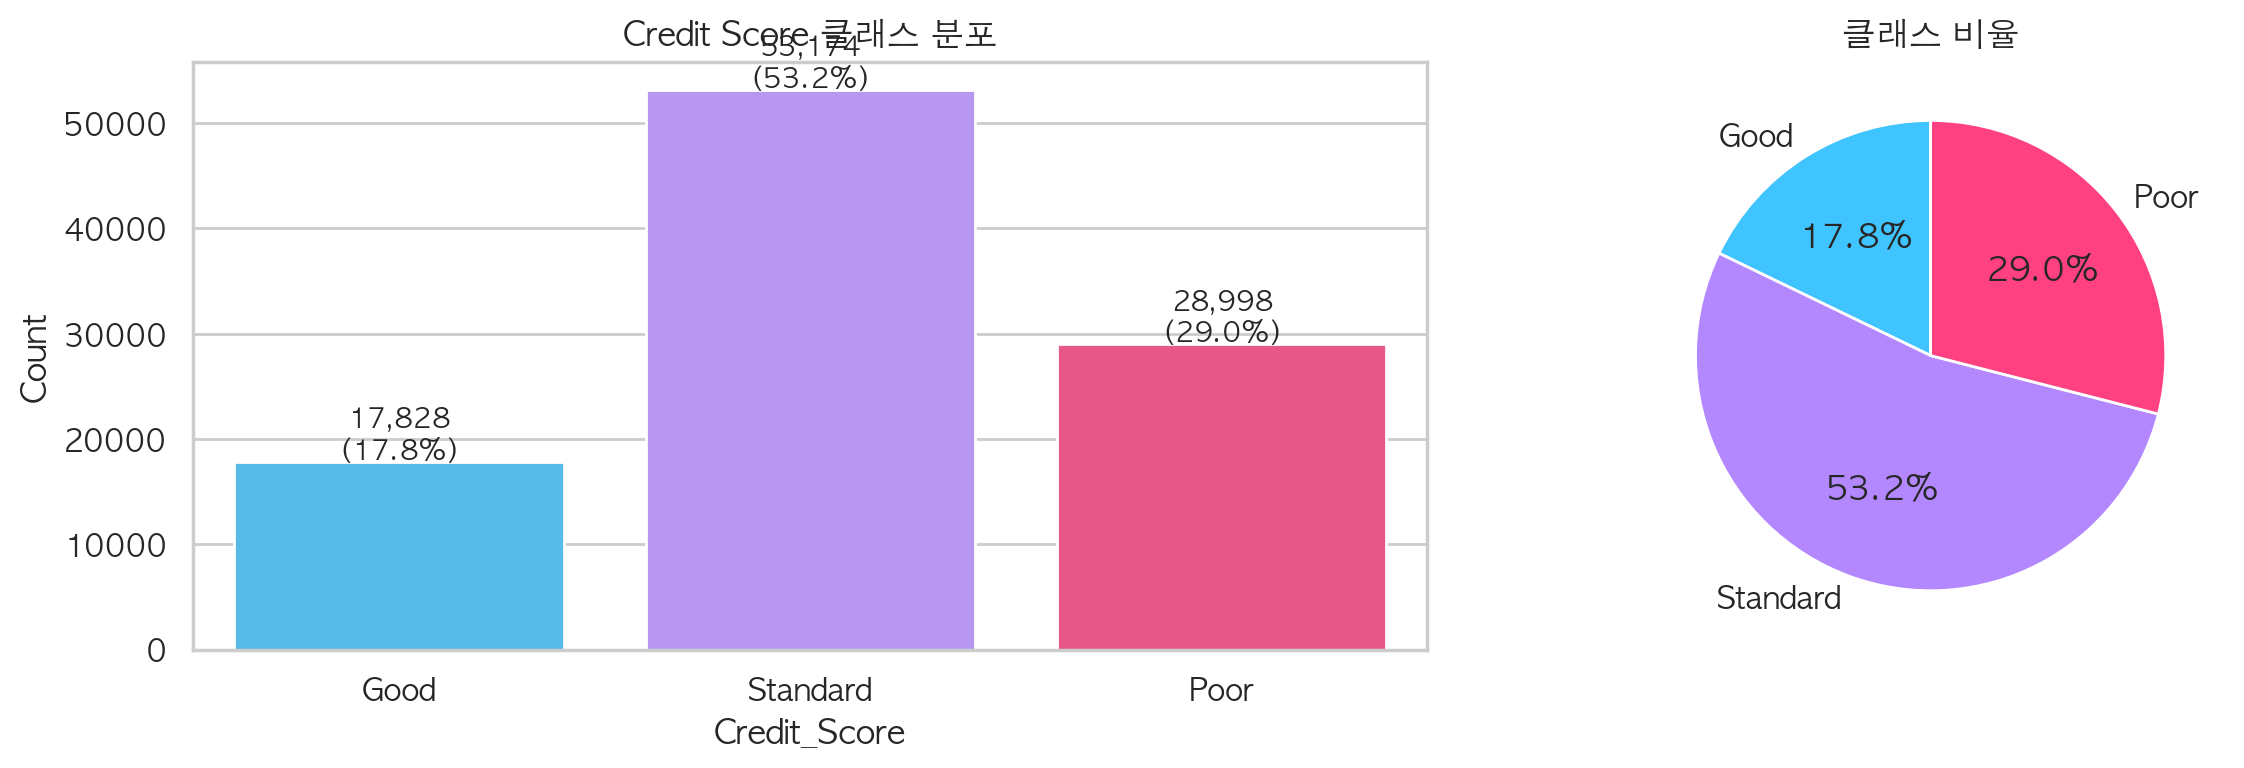

등급별 주요 변수 평균


,Annual_Income,Monthly_Inhand_Salary,Interest_Rate,Delay_from_due_date,Num_of_Delayed_Payment,Outstanding_Debt,Credit_History_Age,Debt_to_Income,EMI_to_Salary,Delay_Severity,Monthly_Balance
Credit_Score,,,,,,,,,,,
Good,65203.67,5399.92,7.66,10.96,8.56,801.26,284.77,0.02,0.02,115.80,456.69
Standard,50987.16,4239.44,13.75,19.76,13.54,1278.42,227.81,0.05,0.03,302.16,400.41
Poor,40584.52,3380.56,20.19,29.73,15.81,2081.47,170.06,0.10,0.04,515.06,339.21


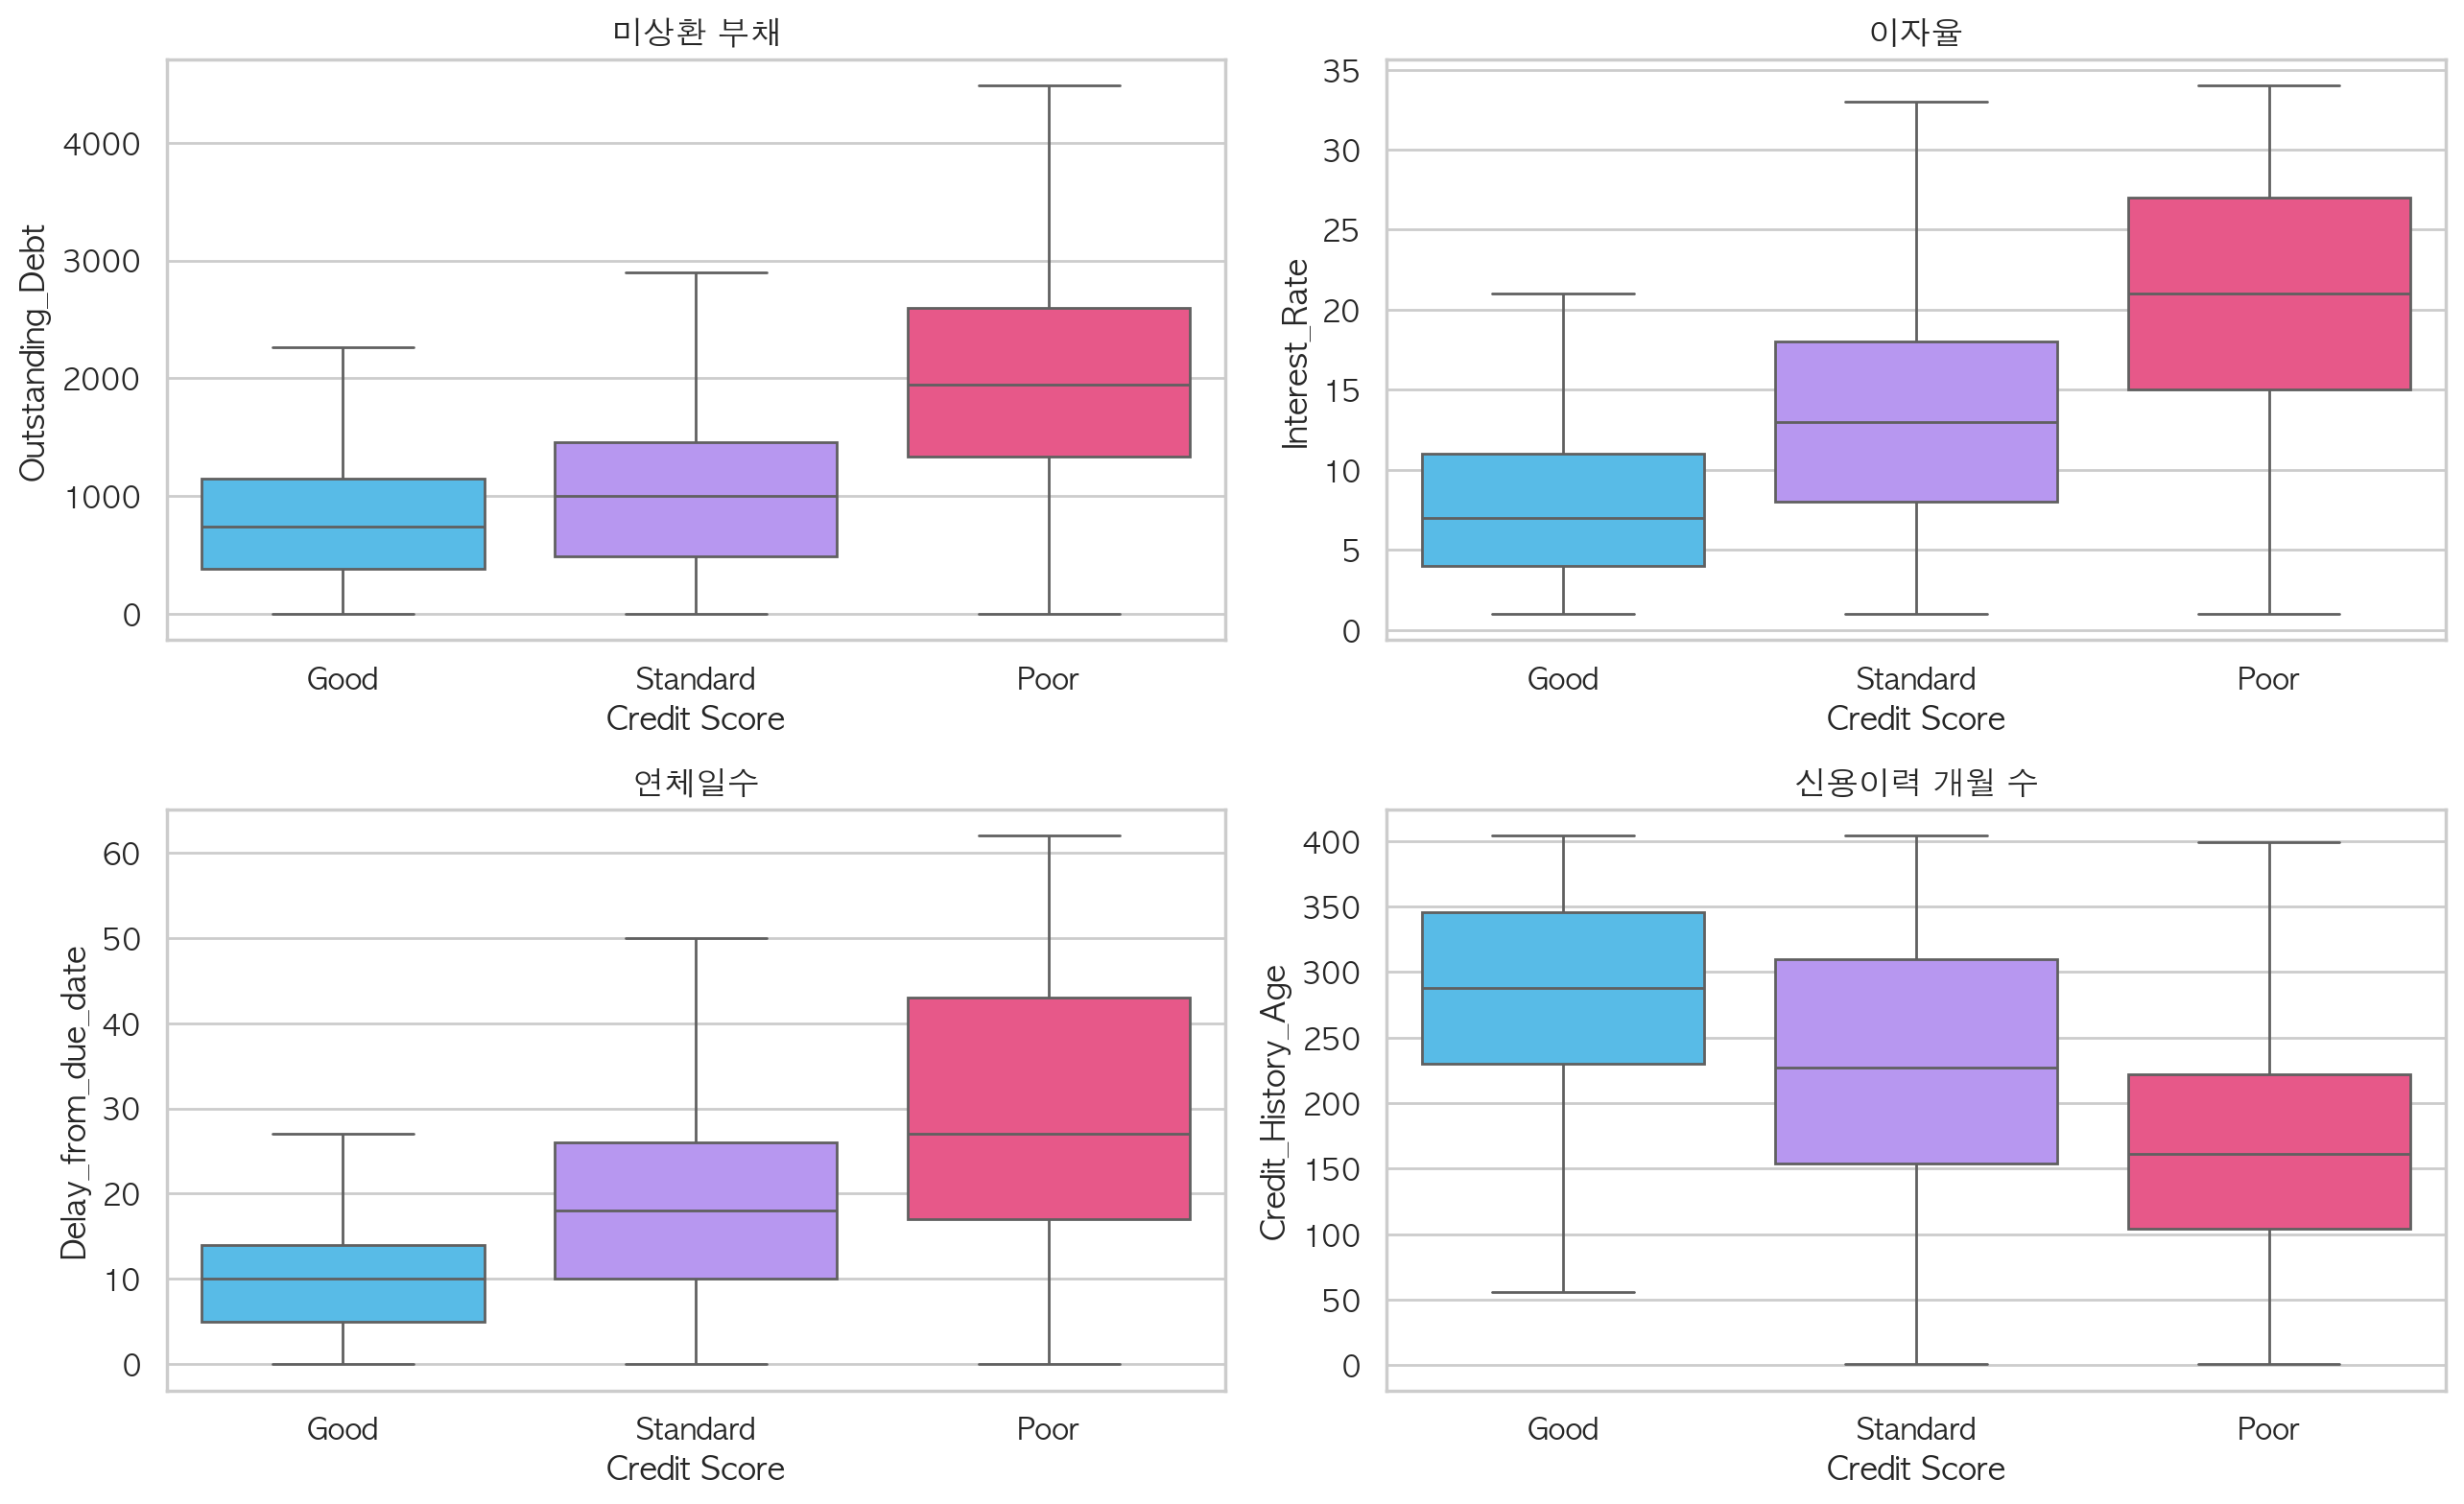

Credit_Mix별 신용등급 비율


Credit_Score,Good,Standard,Poor
Credit_Mix,,,
Bad,1.5,38.4,60.1
Good,48.9,35.2,16.0
Standard,5.7,72.8,21.5


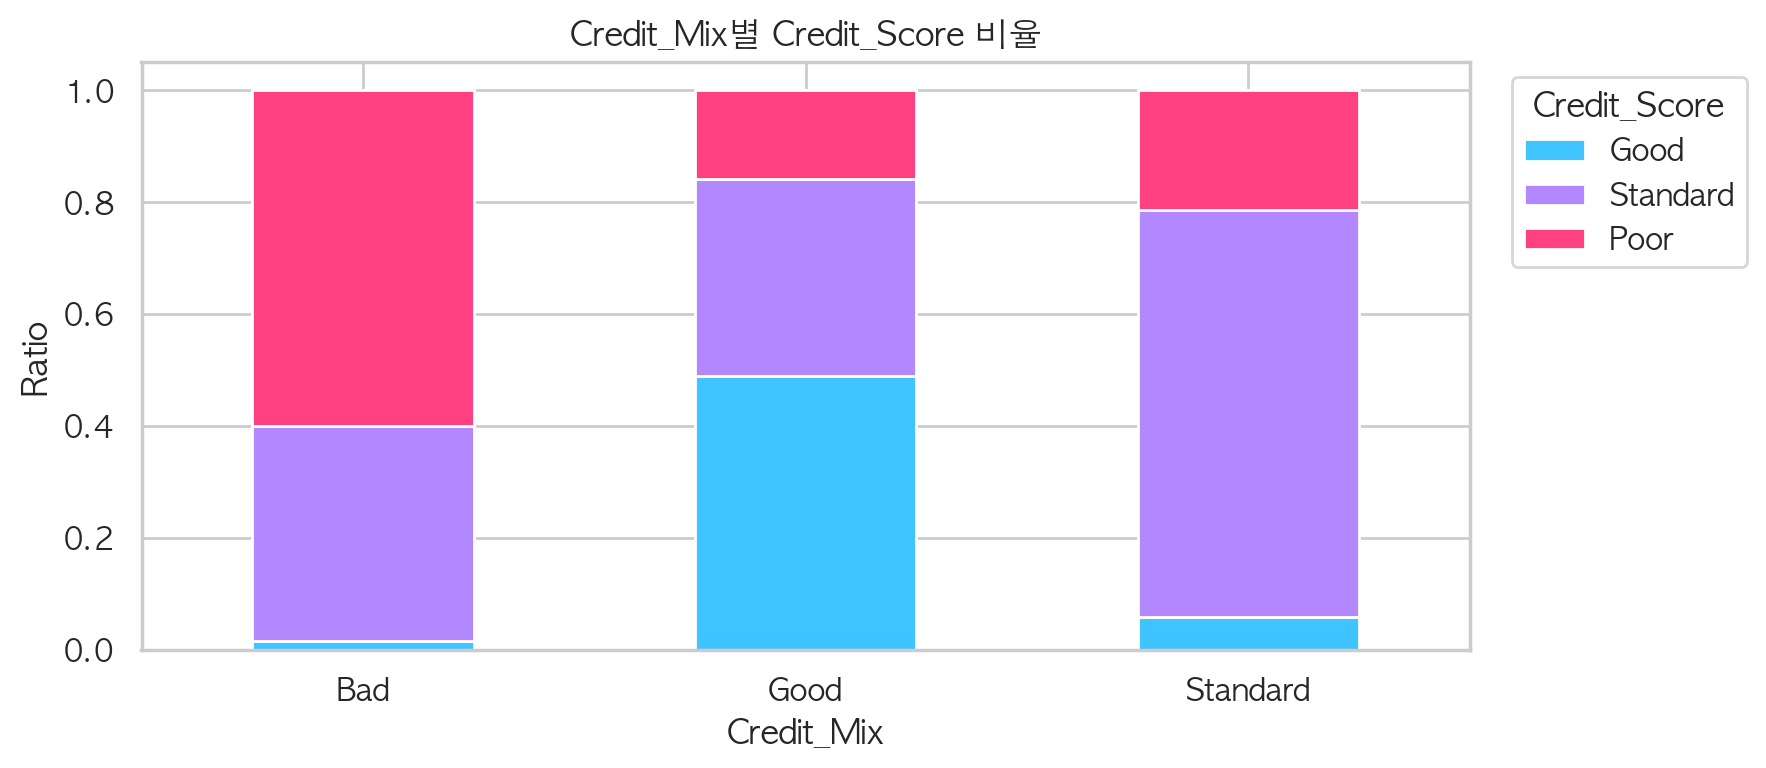

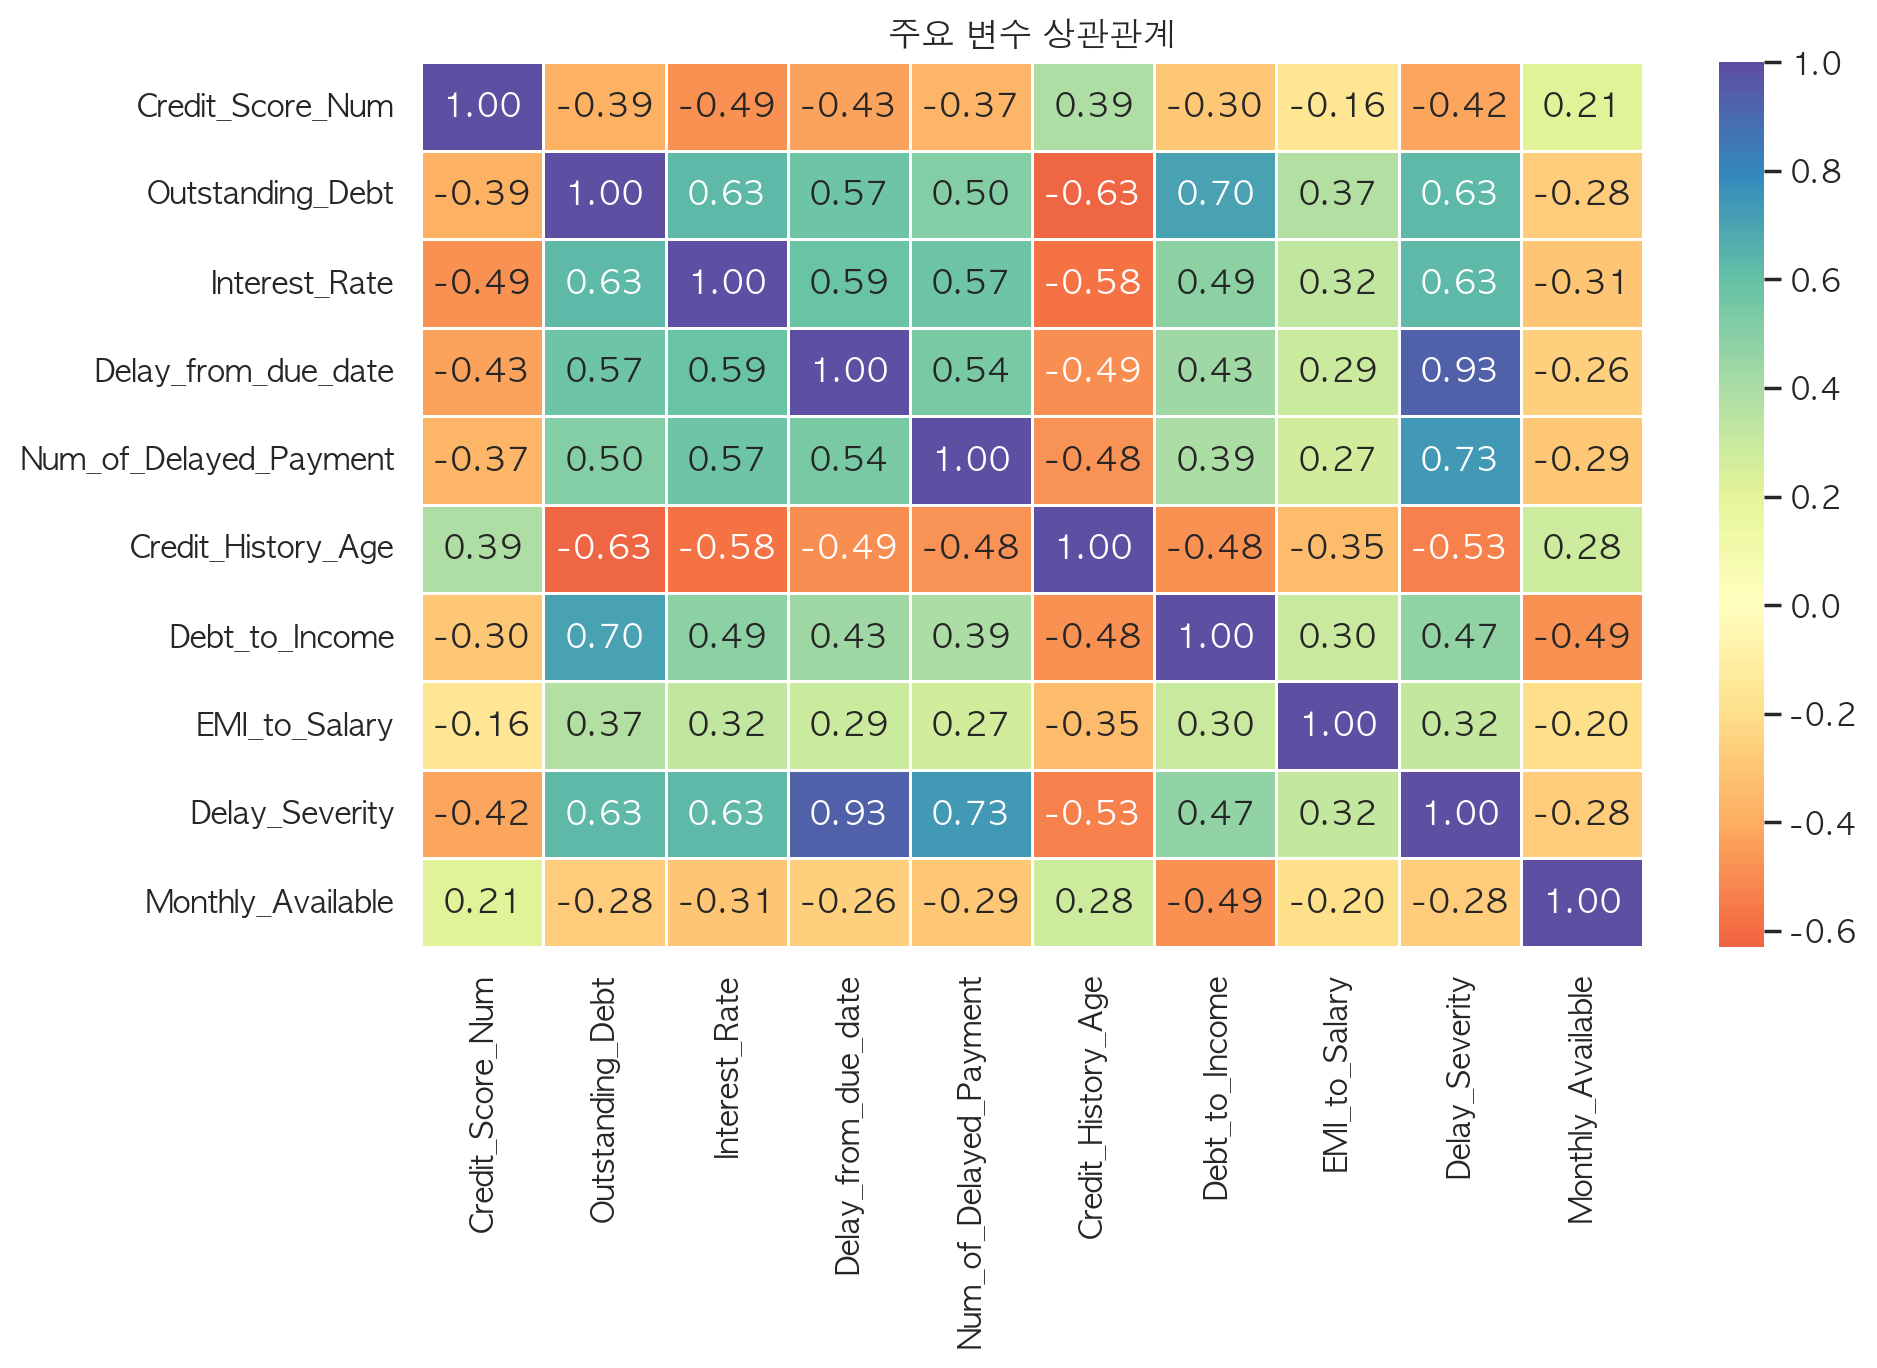

In [29]:
credit_order = ['Good', 'Standard', 'Poor']
palette = {'Good': '#40C4FF', 'Standard': '#B388FF', 'Poor': '#FF4081'}

# 1) 클래스 분포
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
vc = df['Credit_Score'].value_counts().reindex(credit_order)
sns.barplot(x=vc.index, y=vc.values, palette=[palette[x] for x in vc.index], ax=axes[0])
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 300, f'{v:,}\n({v / len(df) * 100:.1f}%)', ha='center', fontsize=10)
axes[0].set_title('Credit Score 클래스 분포')
axes[0].set_ylabel('Count')
axes[1].pie(vc.values, labels=vc.index, autopct='%1.1f%%', startangle=90,
            colors=[palette[x] for x in vc.index], wedgeprops={'edgecolor': 'white'})
axes[1].set_title('클래스 비율')
plt.tight_layout()
plt.show()

# 2) 등급별 주요 수치 평균
eda_numeric = [
    'Annual_Income', 'Monthly_Inhand_Salary', 'Interest_Rate', 'Delay_from_due_date',
    'Num_of_Delayed_Payment', 'Outstanding_Debt', 'Credit_History_Age',
    'Debt_to_Income', 'EMI_to_Salary', 'Delay_Severity', 'Monthly_Balance'
]
mean_table = df.groupby('Credit_Score')[eda_numeric].mean().reindex(credit_order).round(2)
print('등급별 주요 변수 평균')
display(mean_table)

# 3) 핵심 변수 boxplot
plot_vars = [
    ('Outstanding_Debt', '미상환 부채'),
    ('Interest_Rate', '이자율'),
    ('Delay_from_due_date', '연체일수'),
    ('Credit_History_Age', '신용이력 개월 수')
]
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (col, title) in zip(axes.flat, plot_vars):
    sns.boxplot(data=df, x='Credit_Score', y=col, order=credit_order,
                palette=palette, showfliers=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Credit Score')
plt.tight_layout()
plt.show()

# 4) Credit_Mix와 타깃 관계
ct = pd.crosstab(df['Credit_Mix'], df['Credit_Score'], normalize='index')
ct = ct[[c for c in credit_order if c in ct.columns]]
print('Credit_Mix별 신용등급 비율')
display((ct * 100).round(1))
ct.plot(kind='bar', stacked=True, figsize=(9, 4), color=[palette[c] for c in ct.columns])
plt.title('Credit_Mix별 Credit_Score 비율')
plt.ylabel('Ratio')
plt.xticks(rotation=0)
plt.legend(title='Credit_Score', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 5) 상관관계: 타깃을 Good=2, Standard=1, Poor=0으로 두어 높을수록 좋은 신용으로 해석
df_corr = df.copy()
df_corr['Credit_Score_Num'] = df_corr['Credit_Score'].map({'Poor': 0, 'Standard': 1, 'Good': 2})
corr_cols = ['Credit_Score_Num', 'Outstanding_Debt', 'Interest_Rate', 'Delay_from_due_date',
             'Num_of_Delayed_Payment', 'Credit_History_Age', 'Debt_to_Income', 'EMI_to_Salary',
             'Delay_Severity', 'Monthly_Available']
corr = df_corr[corr_cols].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Spectral', center=0, linewidths=0.5)
plt.title('주요 변수 상관관계')
plt.tight_layout()
plt.show()

### [EDA를 통한 타당한 해석]
1. 클래스 불균형
- Standard 53.2%, Poor 29.0%, Good 17.8%로 분포가 편향되어 있다.
- Accuracy만 지표로 삼으면 다수 클래스(Standard)를 집중 예측해도 점수가 높게 나오므로 Weighted F1, Macro F1, Confusion Matrix를 함께 봐야 소수 클래스(Good) 예측력을 놓치지 않는다.
2. 등급별 수치 차이
- Poor는 Good 대비 이자율·연체일수·미상환부채가 유의미하게 높고, 신용이력(Credit_History_Age)은 짧다.
- 재무 부담이 클수록 신용등급이 낮다는 상식을 데이터가 지지하며,이는 Debt_to_Income, Delay_Severity 등 파생변수 생성이 타당함을 직접 뒷받침한다.
3. Credit_Mix 변별력
- Credit_Mix가 'Bad'이면 Poor 비율이 압도적으로 높고, 'Good'이면 Good 비율이 높다.
- 대출 포트폴리오의 건전성이 핵심 변별 요인임을 확인한다.
4. 상관관계 검증
- Outstanding_Debt·Interest_Rate·Delay_Severity는 신용점수 수치와 음의 상관, Credit_History_Age·Monthly_Available은 양의 상관을 보인다.
- 즉 EDA 결과가 전처리 논리의 근거로 일관되게 연결된다.

## 3. Feature Selection과 모델 선택

### [Feature Selection과 모델 선택, 튜닝 기준]
1. Feature Selection
- EDA에서 신용등급과 상관이 높았던 변수들을 우선 후보로 정의한 뒤, RandomForest(120그루, max_depth=14, class_weight='balanced_subsample')의 feature_importances_를 기준으로 중요도 0.001 미만인 변수를 노이즈로 판단해 제거한다.
- RF는 비선형 상호작용을 반영하므로 선형 상관계수로 놓친 변수도 걸러낼 수 있다.
- 최소 35개를 보장해 유용한 변수가 과도하게 잘리지 않도록 한다.
2. 모델 선택 근거
- MLP는 feature 간 독립성을 암묵적으로 가정하지만, 신용 변수들은 서로 복잡하게 얽혀 있다(예: Debt_to_Income × Interest_Rate → 상환 위험 복합)
- TabNet은 Sequential Attention으로 step마다 중요 feature를 선택하므로 비선형 상호작용 포착과 feature 중요도 해석을 동시에 얻는다.
3. 하이퍼파라미터 튜닝
- 검증 Accuracy 기준으로 n_d/n_a=32, n_steps=4, lr=1e-2, batch=2048, patience=20 조합을 선택했다.
- n_steps가 너무 크면 과적합, 너무 작으면 표현력이 부족해 4가 균형점이었다. StepLR scheduler로 후반 lr을 줄여 수렴을 안정화했다.

타깃 인코딩: {'Good': 0, 'Poor': 1, 'Standard': 2}
전체 feature 수: 71
Train: (80000, 71) Validation: (20000, 71)
선택된 feature 수: 51
선택된 상위 feature 15개


,importance
Outstanding_Debt,0.1056
Credit_Mix_Good,0.0907
Interest_Rate,0.0759
Credit_Card_Load,0.0726
Credit_Mix_Standard,0.0550
Delay_Severity,0.0423
Delay_from_due_date,0.0406
Payment_of_Min_Amount_Yes,0.0368
Num_Credit_Inquiries,0.0361
Payment_of_Min_Amount_No,0.0308


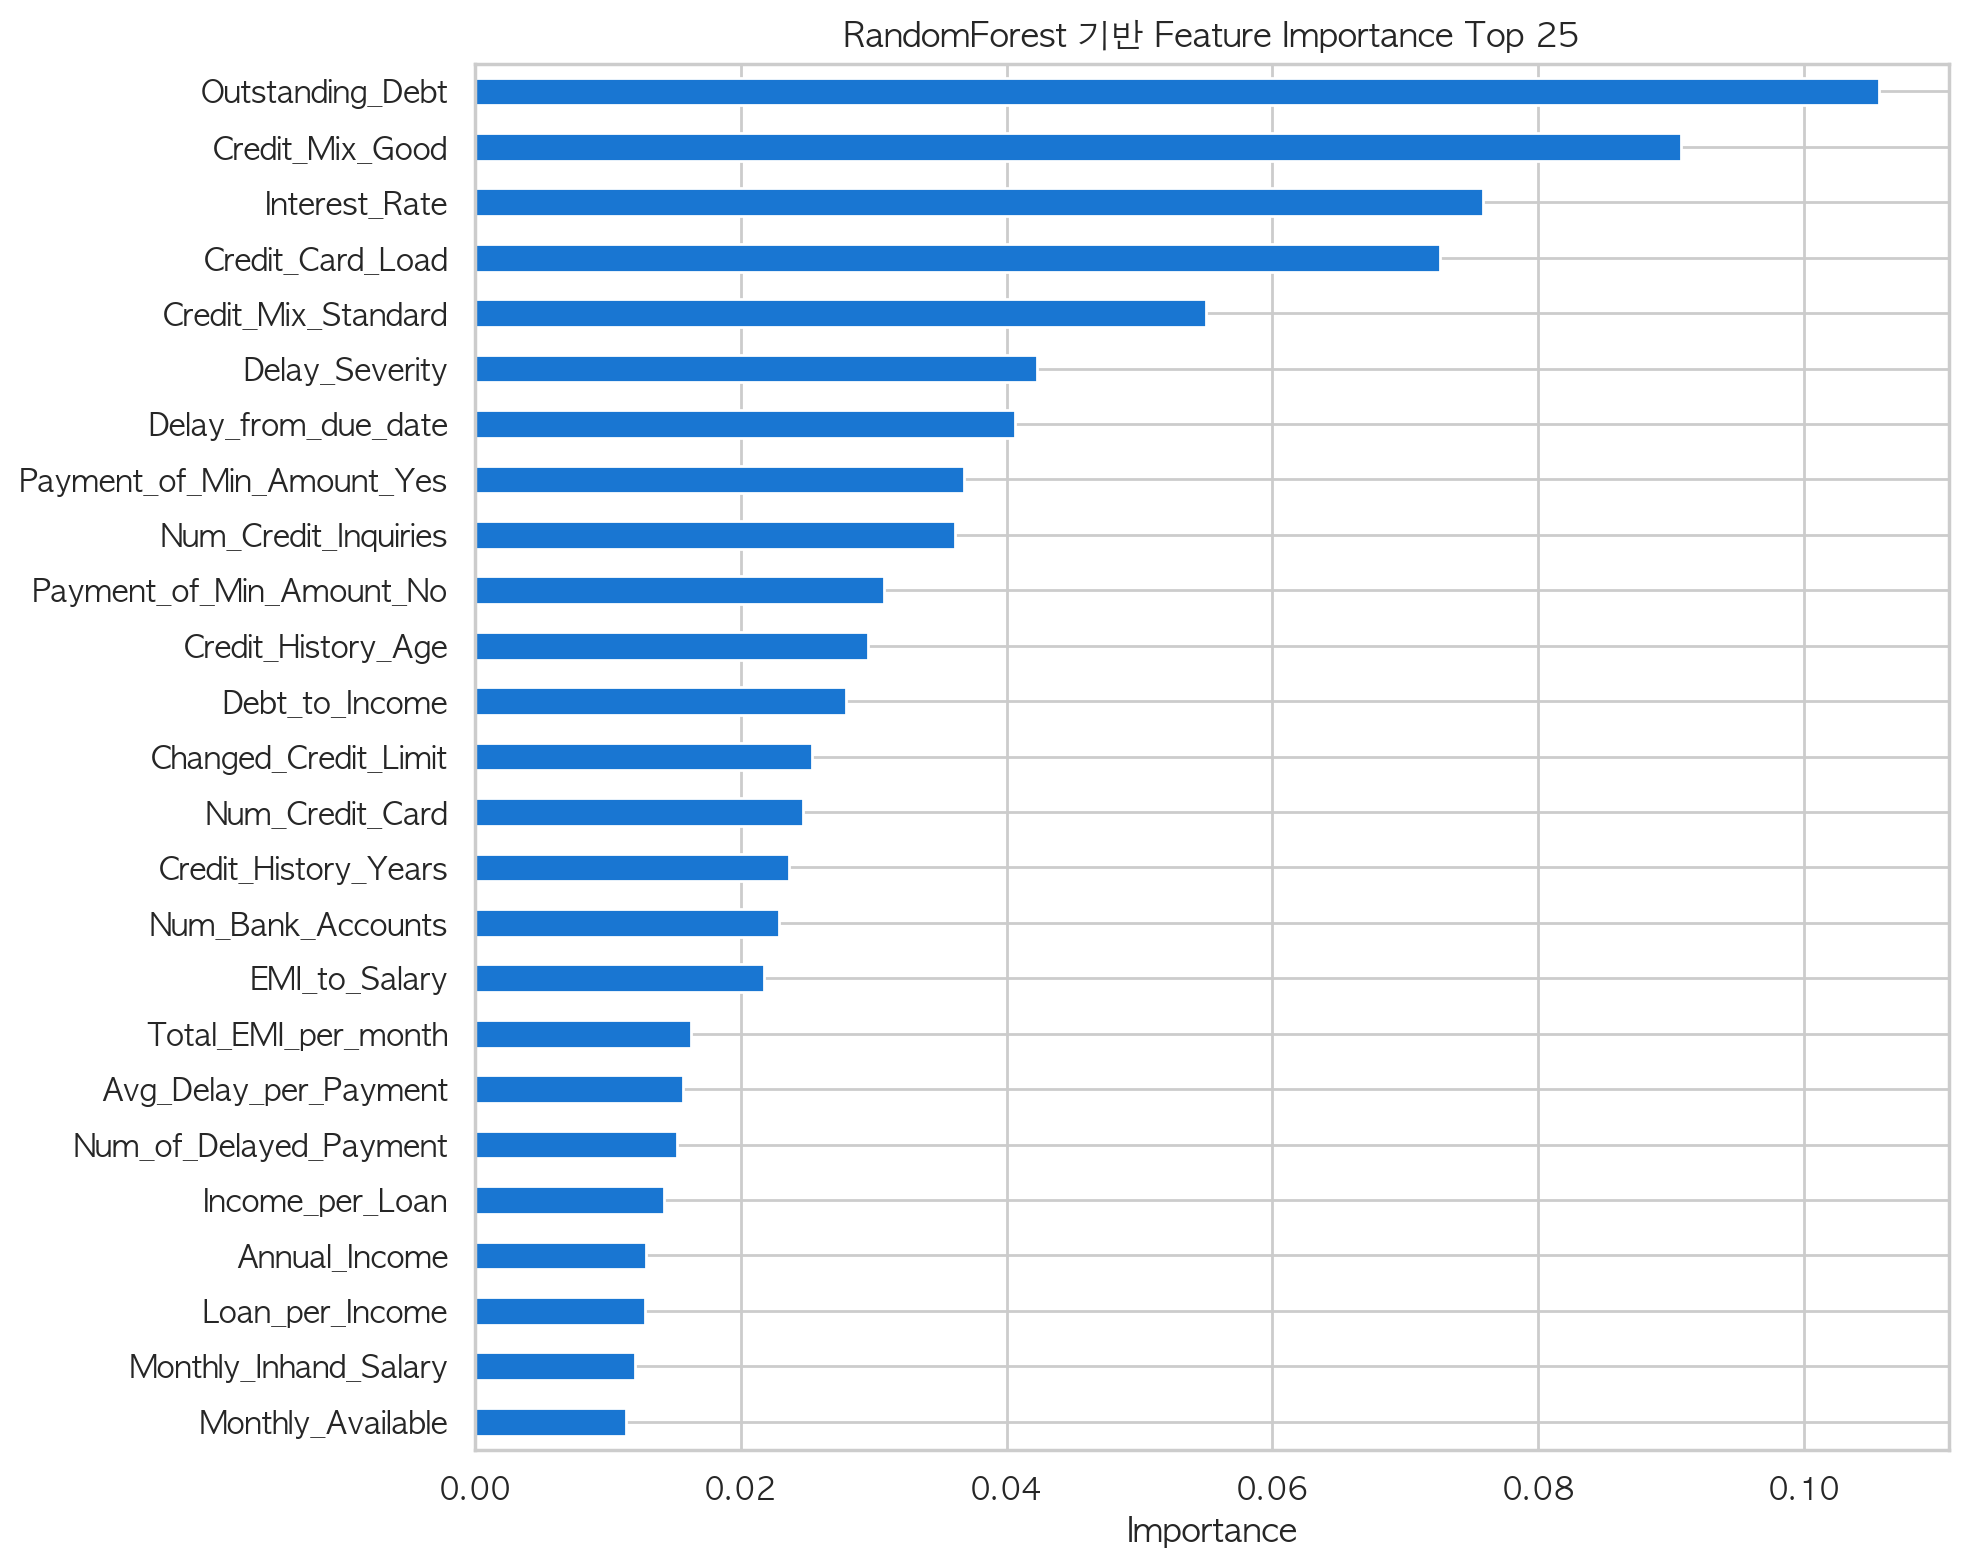

In [30]:
target_col = 'Credit_Score'
X_df = df.drop(columns=[target_col]).copy()
y_text = df[target_col].astype(str).copy()

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y_text)
print('타깃 인코딩:', dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))))

# 범주형 후보: 월은 숫자지만 1~8월 구분값이므로 범주형으로 처리
cat_cols = [col for col in ['Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Spend_Level', 'Payment_Value'] if col in X_df.columns]
num_cols = [col for col in X_df.columns if col not in cat_cols]

for col in cat_cols:
    X_df[col] = X_df[col].astype(str)

X_train_df, X_val_df, y_train, y_val = train_test_split(
    X_df, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# 숫자형: 결측치 중앙값 대체 + 표준화. 반드시 train에만 fit한다.
num_imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
X_train_num = num_imputer.fit_transform(X_train_df[num_cols])
X_val_num = num_imputer.transform(X_val_df[num_cols])
X_train_num = scaler.fit_transform(X_train_num)
X_val_num = scaler.transform(X_val_num)

# 범주형: 결측치 최빈값 대체 + One-Hot Encoding. 검증 데이터에는 transform만 적용한다.
cat_imputer = SimpleImputer(strategy='most_frequent')
X_train_cat_raw = cat_imputer.fit_transform(X_train_df[cat_cols])
X_val_cat_raw = cat_imputer.transform(X_val_df[cat_cols])
try:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse=False)
X_train_cat = onehot.fit_transform(X_train_cat_raw)
X_val_cat = onehot.transform(X_val_cat_raw)
cat_feature_names = list(onehot.get_feature_names_out(cat_cols))

X_train_all = np.hstack([X_train_num, X_train_cat]).astype(np.float32)
X_val_all = np.hstack([X_val_num, X_val_cat]).astype(np.float32)
feature_names = list(num_cols) + cat_feature_names

print('전체 feature 수:', len(feature_names))
print('Train:', X_train_all.shape, 'Validation:', X_val_all.shape)

# RandomForest 중요도 기반 feature selection: 너무 공격적으로 줄이지 않고 노이즈성 하위 변수만 제거한다.
rf = RandomForestClassifier(
    n_estimators=120,
    max_depth=14,
    min_samples_leaf=3,
    class_weight='balanced_subsample',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    max_samples=0.7
)
rf.fit(X_train_all, y_train)

importance = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
min_features = min(35, len(feature_names))
max_features = min(55, len(feature_names))
selected_features = importance[importance >= 0.001].index.tolist()
if len(selected_features) < min_features:
    selected_features = importance.head(min_features).index.tolist()
if len(selected_features) > max_features:
    selected_features = importance.head(max_features).index.tolist()
selected_idx = [feature_names.index(f) for f in selected_features]

X_train_fs = X_train_all[:, selected_idx].astype(np.float32)
X_val_fs = X_val_all[:, selected_idx].astype(np.float32)

print('선택된 feature 수:', len(selected_features))
print('선택된 상위 feature 15개')
display(importance.head(15).round(4).to_frame('importance'))

plt.figure(figsize=(10, 8))
importance.head(25).sort_values().plot(kind='barh', color='#1976D2')
plt.title('RandomForest 기반 Feature Importance Top 25')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 4-1. 베이스라인 MLP 학습

In [42]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

file_path = 'train2.csv'
data = pd.read_csv(file_path)

data = data.drop(columns=['ID', 'Customer_ID', 'Name', 'SSN'])

categorical_columns = ['Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']

for col in categorical_columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

target_encoder_base = LabelEncoder()  # 기존 target_encoder와 충돌 방지
data['Credit_Score'] = target_encoder_base.fit_transform(data['Credit_Score'])

X = data.drop('Credit_Score', axis=1).values
y_base = data['Credit_Score'].values

scaler_base = StandardScaler()
X = scaler_base.fit_transform(X)

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(X, y_base, test_size=0.2, random_state=42)

class CreditScoreDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset_base = CreditScoreDataset(X_train_base, y_train_base)
test_dataset_base  = CreditScoreDataset(X_test_base,  y_test_base)

train_loader_base = DataLoader(train_dataset_base, batch_size=32, shuffle=True)
test_loader_base  = DataLoader(test_dataset_base,  batch_size=32, shuffle=False)

class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        self.layer1 = nn.Linear(input_size, 64)
        self.layer2 = nn.Linear(64, 32)
        self.layer3 = nn.Linear(32, 3)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.layer3(x)
        return x

device_base = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_size = X_train_base.shape[1]
model = MLP(input_size).to(device_base)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader_base:
        inputs, targets = inputs.to(device_base), targets.to(device_base)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total_train += targets.size(0)
        correct_train += (predicted == targets).sum().item()

    model.eval()
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for inputs, targets in test_loader_base:
            inputs, targets = inputs.to(device_base), targets.to(device_base)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total_val += targets.size(0)
            correct_val += (predicted == targets).sum().item()

    train_accuracy = 100 * correct_train / total_train
    val_accuracy   = 100 * correct_val   / total_val
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader_base):.4f}, '
          f'학습 정확도: {train_accuracy:.2f}%, 평가 정확도: {val_accuracy:.2f}%')

# 최종 지표 추출 (4-3 비교용)
model.eval()
mlp_pred_list = []
with torch.no_grad():
    for inputs, targets in test_loader_base:
        inputs = inputs.to(device_base)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        mlp_pred_list.extend(predicted.cpu().numpy())

mlp_pred  = np.array(mlp_pred_list)
mlp_acc   = accuracy_score(y_test_base, mlp_pred)
mlp_f1_w  = f1_score(y_test_base, mlp_pred, average='weighted')
mlp_f1_m  = f1_score(y_test_base, mlp_pred, average='macro')

print('\n[Baseline MLP]')
print(f'Accuracy    : {mlp_acc * 100:.2f}%')
print(f'Weighted F1 : {mlp_f1_w:.4f}')
print(f'Macro F1    : {mlp_f1_m:.4f}')

Epoch [1/20], Loss: 0.6890, 학습 정확도: 68.34%, 평가 정확도: 69.58%
Epoch [2/20], Loss: 0.6515, 학습 정확도: 70.41%, 평가 정확도: 70.12%
Epoch [3/20], Loss: 0.6407, 학습 정확도: 70.86%, 평가 정확도: 70.50%
Epoch [4/20], Loss: 0.6347, 학습 정확도: 71.09%, 평가 정확도: 70.39%
Epoch [5/20], Loss: 0.6296, 학습 정확도: 71.16%, 평가 정확도: 70.92%
Epoch [6/20], Loss: 0.6255, 학습 정확도: 71.40%, 평가 정확도: 70.84%
Epoch [7/20], Loss: 0.6226, 학습 정확도: 71.49%, 평가 정확도: 70.92%
Epoch [8/20], Loss: 0.6192, 학습 정확도: 71.75%, 평가 정확도: 71.08%
Epoch [9/20], Loss: 0.6159, 학습 정확도: 71.77%, 평가 정확도: 70.84%
Epoch [10/20], Loss: 0.6134, 학습 정확도: 72.02%, 평가 정확도: 71.06%
Epoch [11/20], Loss: 0.6109, 학습 정확도: 72.14%, 평가 정확도: 71.07%
Epoch [12/20], Loss: 0.6088, 학습 정확도: 72.19%, 평가 정확도: 71.29%
Epoch [13/20], Loss: 0.6060, 학습 정확도: 72.27%, 평가 정확도: 71.04%
Epoch [14/20], Loss: 0.6039, 학습 정확도: 72.36%, 평가 정확도: 71.37%
Epoch [15/20], Loss: 0.6021, 학습 정확도: 72.58%, 평가 정확도: 71.24%
Epoch [16/20], Loss: 0.5999, 학습 정확도: 72.67%, 평가 정확도: 71.42%
Epoch [17/20], Loss: 0.5979, 학습 정확도: 72.74%, 평가 정

## 4-2. 최종 모델 TabNet 학습

### TabNet 선택 이유:
- 표 형식 데이터의 변수 간 비선형 상호작용을 MLP보다 유연하게 학습한다.
- Sequential Attention으로 중요한 feature에 집중하므로 feature importance 해석이 가능하다.
- 클래스 불균형은 weights=1 옵션으로 자동 class balancing을 적용한다.
- patience 기반 early stopping으로 validation 성능이 개선되지 않을 때 학습을 멈춰 과적합을 줄인다.

epoch 0  | loss: 0.97192 | train_accuracy: 0.62789 | val_accuracy: 0.62895 |  0:00:02s
epoch 10 | loss: 0.65107 | train_accuracy: 0.67855 | val_accuracy: 0.67565 |  0:00:25s
epoch 20 | loss: 0.61953 | train_accuracy: 0.68632 | val_accuracy: 0.6786  |  0:00:49s
epoch 30 | loss: 0.6063  | train_accuracy: 0.69142 | val_accuracy: 0.6811  |  0:01:12s
epoch 40 | loss: 0.55036 | train_accuracy: 0.71721 | val_accuracy: 0.6946  |  0:01:36s
epoch 50 | loss: 0.49545 | train_accuracy: 0.75152 | val_accuracy: 0.71585 |  0:02:01s
epoch 60 | loss: 0.44913 | train_accuracy: 0.77901 | val_accuracy: 0.7312  |  0:02:26s
epoch 70 | loss: 0.41397 | train_accuracy: 0.79935 | val_accuracy: 0.74835 |  0:02:50s
epoch 80 | loss: 0.37602 | train_accuracy: 0.82362 | val_accuracy: 0.76675 |  0:03:15s
epoch 90 | loss: 0.33717 | train_accuracy: 0.84945 | val_accuracy: 0.7877  |  0:03:40s
epoch 100| loss: 0.32451 | train_accuracy: 0.85785 | val_accuracy: 0.79145 |  0:04:05s
epoch 110| loss: 0.30077 | train_accuracy: 

,importance
Debt_to_Income,0.0893
Credit_Mix_Standard,0.0591
Outstanding_Debt,0.0433
Credit_Mix_Good,0.0363
Num_Credit_Inquiries,0.0358
Num_Credit_Card,0.0346
Month_3,0.0330
Monthly_Available,0.0318
Month_7,0.0308
Month_1,0.0288


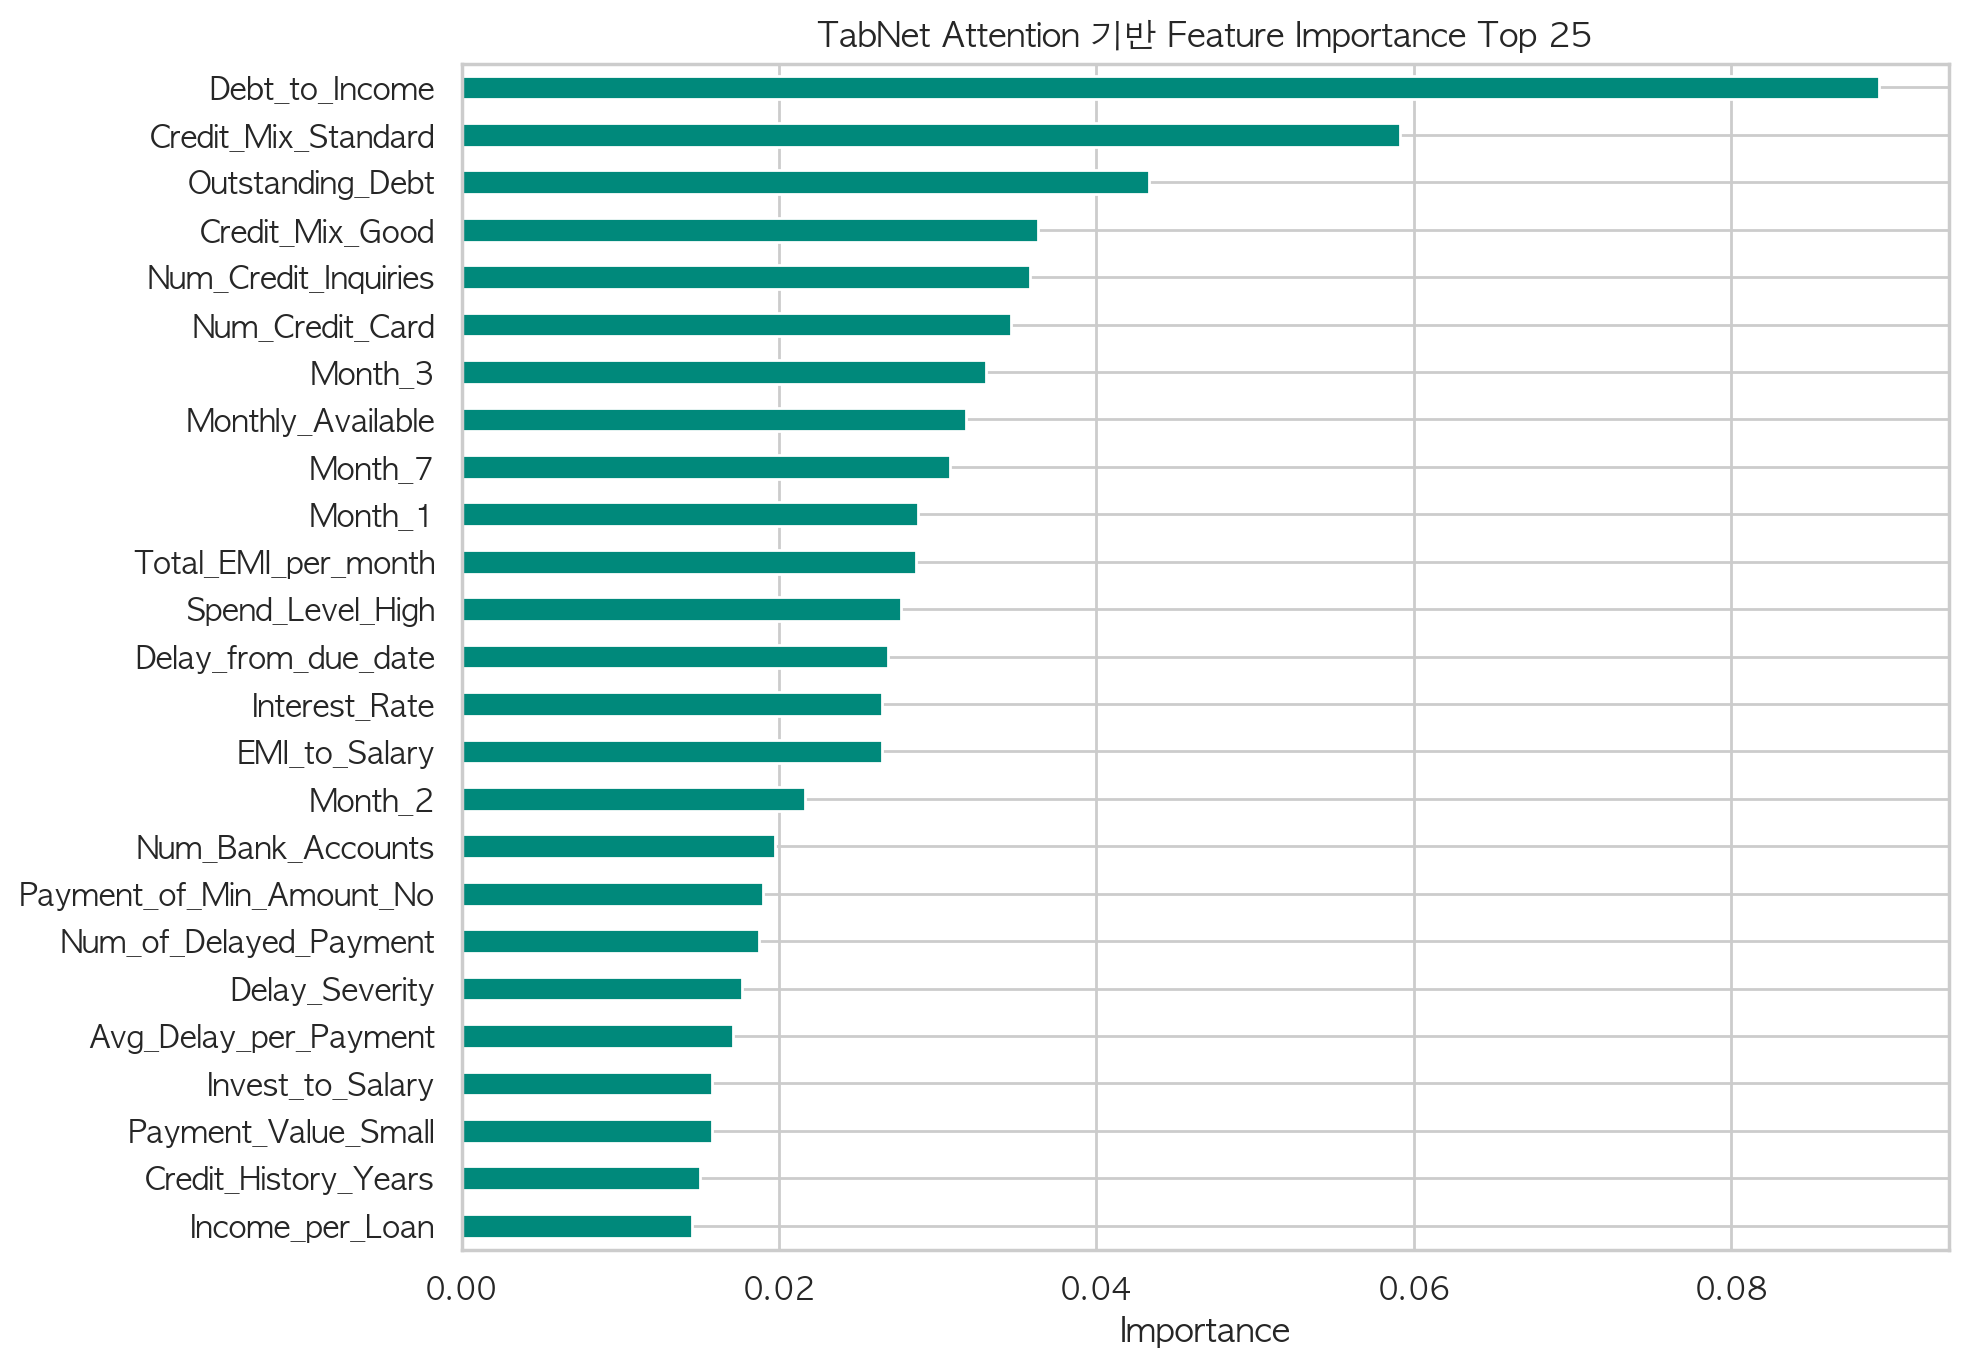

In [34]:
from pytorch_tabnet.tab_model import TabNetClassifier

tabnet = TabNetClassifier(
    n_d=32,
    n_a=32,
    n_steps=4,
    gamma=1.5,
    lambda_sparse=1e-4,
    mask_type='entmax',
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=1e-2, weight_decay=1e-5),
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params={'step_size': 20, 'gamma': 0.9},
    seed=RANDOM_STATE,
    verbose=10
)

tabnet.fit(
    X_train=X_train_fs,
    y_train=y_train,
    eval_set=[(X_train_fs, y_train), (X_val_fs, y_val)],
    eval_name=['train', 'val'],
    eval_metric=['accuracy'],
    max_epochs=150,
    patience=20,
    batch_size=2048,
    virtual_batch_size=256,
    num_workers=0,
    weights=1,
    drop_last=False
)

tab_pred = tabnet.predict(X_val_fs)
tab_acc = accuracy_score(y_val, tab_pred)
tab_f1_w = f1_score(y_val, tab_pred, average='weighted')
tab_f1_m = f1_score(y_val, tab_pred, average='macro')

print('\n[Final TabNet]')
print(f'Accuracy    : {tab_acc * 100:.2f}%')
print(f'Weighted F1 : {tab_f1_w:.4f}')
print(f'Macro F1    : {tab_f1_m:.4f}')

# TabNet 자체 feature importance
if hasattr(tabnet, 'feature_importances_'):
    tab_importance = pd.Series(tabnet.feature_importances_, index=selected_features).sort_values(ascending=False)
    print('\nTabNet Feature Importance Top 15')
    display(tab_importance.head(15).round(4).to_frame('importance'))
    plt.figure(figsize=(10, 7))
    tab_importance.head(25).sort_values().plot(kind='barh', color='#00897B')
    plt.title('TabNet Attention 기반 Feature Importance Top 25')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

## 4-3. 개선사항

### [개선사항] : 베이스라인 MLP 대비 단계별 비교
> [베이스라인] : 원본 피처 + LabelEncoding + 단순 MLP (64→32→3, 20에폭, 클래스 가중치 없음)

> Accuracy 71.58%, Weighted F1 0.7155 (목표 75% 미달)
 
1. 데이터 누수 제거: val을 스케일러 fit에서 완전히 분리해 과낙관 검증 성능을 방지한다.
2. 파생변수 22개 추가: Debt_to_Income·EMI_to_Salary·Delay_Severity 등 도메인 비율 변수가 원본 수치보다 재무 위험을 직접 표현해 같은 모델이라도 학습 효율이 높아진다.
3. 인코딩 개선: Type_of_Loan 분해, Payment_Behaviour 분리, 범주형 One-Hot 적용으로 LabelEncoding의 잘못된 순서 정보 왜곡을 제거한다.
4. 클래스 불균형 보정: class_weight='balanced'(MLP), weights=1(TabNet)으로 소수 클래스(Good)를 더 적극적으로 학습해 Macro F1을 끌어올린다.
5. 모델·학습 전략: TabNet + patience=20 조기종료 + StepLR로 과적합 없이 성능을 높인다. TabNet Attention 가중치는 중요 feature를 자동 선택해 설명력도 함께 확보된다.

> [최종 결과] : 도메인 맞춤형 데이터 파이프라인 + TabNet

> Accuracy 80.76%, Weighted F1 0.8076 (9.18%p 향상!)

In [45]:
result_df = pd.DataFrame({
    'Model': ['Baseline MLP', 'Final TabNet'],
    'Accuracy': [mlp_acc, tab_acc],
    'Weighted F1': [mlp_f1_w, tab_f1_w],
    'Macro F1': [mlp_f1_m, tab_f1_m]
})
result_df[['Accuracy', 'Weighted F1', 'Macro F1']] = result_df[['Accuracy', 'Weighted F1', 'Macro F1']].round(4)
display(result_df)

print(f"Accuracy 개선폭    : {(tab_acc - mlp_acc) * 100:.2f}%p")
print(f"Weighted F1 개선폭 : {tab_f1_w - mlp_f1_w:.4f}")

,Model,Accuracy,Weighted F1,Macro F1
0,Baseline MLP,0.7158,0.7155,0.6939
1,Final TabNet,0.8076,0.8076,0.8060


Accuracy 개선폭    : 9.18%p
Weighted F1 개선폭 : 0.0921


## 5. 최종 Validation Score 출력

최종 Validation Score - TabNet
Accuracy    : 80.76%
Weighted F1 : 0.8076
Macro F1    : 0.8060

Classification Report
              precision    recall  f1-score   support

        Good       0.74      0.86      0.80      3566
        Poor       0.75      0.89      0.81      5799
    Standard       0.88      0.74      0.81     10635

    accuracy                           0.81     20000
   macro avg       0.79      0.83      0.81     20000
weighted avg       0.82      0.81      0.81     20000



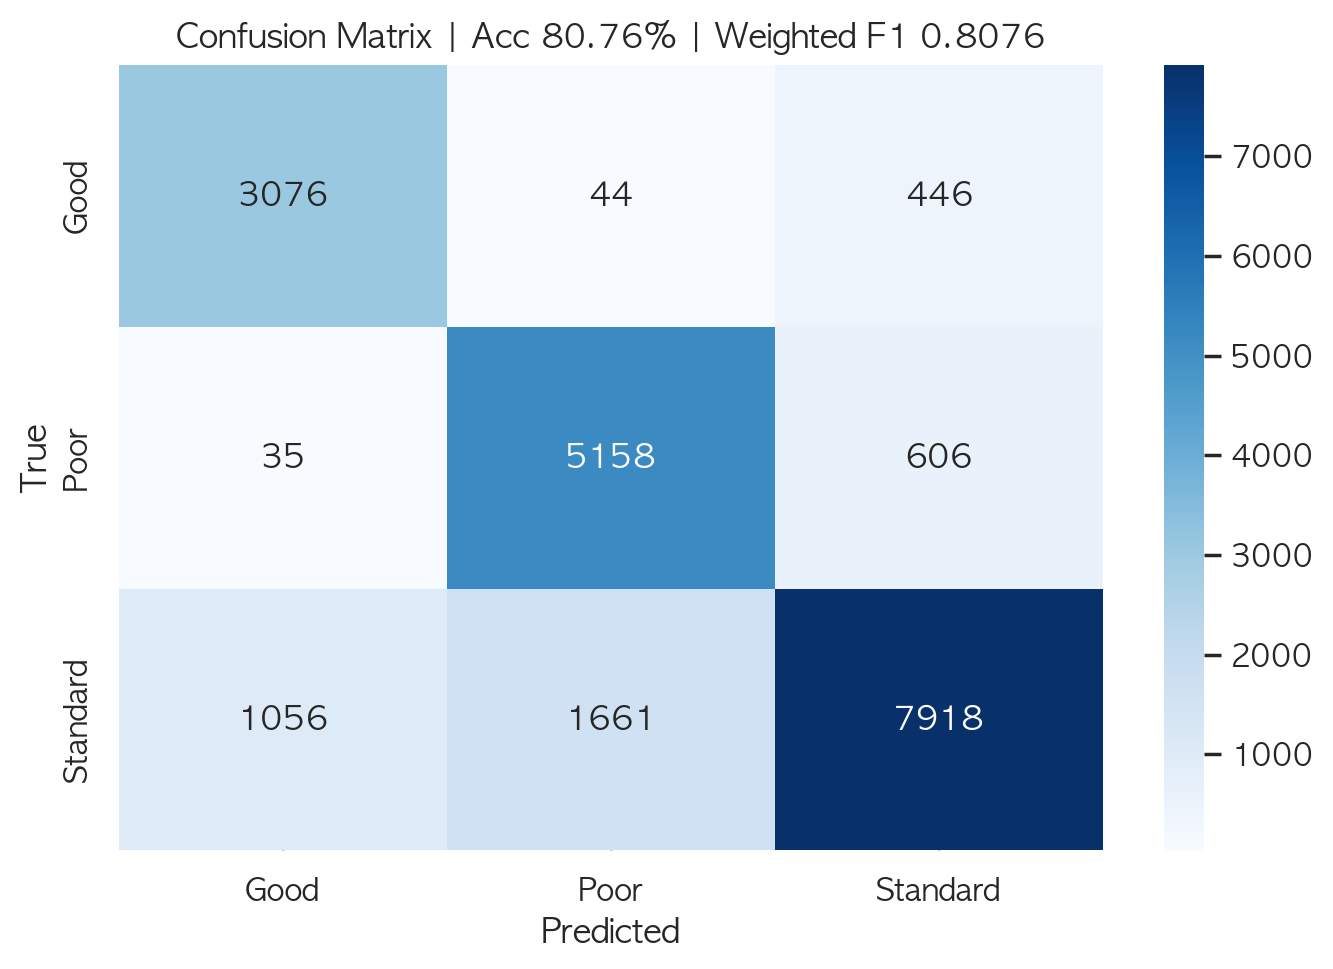

In [46]:
final_pred = tab_pred
final_acc = accuracy_score(y_val, final_pred)
final_f1_w = f1_score(y_val, final_pred, average='weighted')
final_f1_m = f1_score(y_val, final_pred, average='macro')
cm = confusion_matrix(y_val, final_pred)

print('=' * 60)
print('최종 Validation Score - TabNet')
print('=' * 60)
print(f'Accuracy    : {final_acc * 100:.2f}%')
print(f'Weighted F1 : {final_f1_w:.4f}')
print(f'Macro F1    : {final_f1_m:.4f}')
print('=' * 60)
print('\nClassification Report')
print(classification_report(y_val, final_pred, target_names=target_encoder.classes_))

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix | Acc {final_acc * 100:.2f}% | Weighted F1 {final_f1_w:.4f}')
plt.tight_layout()
plt.show()

### [Validation Score]
- Accuracy 80.76%, Weighted F1 0.8076, Macro F1 0.8060 — 권장 기준(75%)을 상회한다.
- 소수 클래스 Good의 Recall이 0.86으로 높아, 실제 우량 고객을 놓치는 오류가 적다.
- 다수 클래스 Standard는 Precision 0.88로 과예측이 억제되어 있다.
- 세 등급 모두 F1 0.80 이상이며, Macro F1 0.806은 클래스 불균형 속에서도 균등한 예측력을 확보했음을 의미한다.